# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from joblib import dump, load
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')


In [ ]:
!pip install ta -q
import ta


  Preparing metadata (setup.py) ... done


# 2. Load Dataset

In [ ]:
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS',
    'GAIL.NS', 'TATASTEEL.NS', 'SBIN.NS', 'AXISBANK.NS', 'WIPRO.NS',
    'HCLTECH.NS', 'ONGC.NS', 'NTPC.NS', 'MARUTI.NS', 'SUNPHARMA.NS',
    'DRREDDY.NS', 'CIPLA.NS', 'ITC.NS', 'LT.NS'
]

all_data = []
for ticker in tickers:
    df = yf.download(ticker, start="2019-01-01", interval="1d", progress=False)
    if df.empty:
        print(f"❌ {ticker}: Empty data")
        continue
    df.columns = df.columns.droplevel(1)
    df.reset_index(inplace=True)
    df.columns.name = None
    df = df[df['Volume'] > 0]
    df['Ticker'] = ticker
    if 'Adj Close' in df.columns:
        df.drop(columns=['Adj Close'], inplace=True)
    all_data.append(df)
    print(f"✅ {ticker}: {len(df)} rows")

combined_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal stocks : {len(all_data)}")
print(f"Total rows   : {len(combined_df)}")


✅ RELIANCE.NS: 1901 rows
✅ TCS.NS: 1901 rows
✅ INFY.NS: 1901 rows
✅ HDFCBANK.NS: 1901 rows
✅ ICICIBANK.NS: 1901 rows
✅ GAIL.NS: 1901 rows
✅ TATASTEEL.NS: 1901 rows
✅ SBIN.NS: 1901 rows
✅ AXISBANK.NS: 1900 rows
✅ WIPRO.NS: 1901 rows
✅ HCLTECH.NS: 1901 rows
✅ ONGC.NS: 1901 rows
✅ NTPC.NS: 1901 rows
✅ MARUTI.NS: 1901 rows
✅ SUNPHARMA.NS: 1901 rows
✅ DRREDDY.NS: 1901 rows
✅ CIPLA.NS: 1900 rows
✅ ITC.NS: 1902 rows
✅ LT.NS: 1901 rows

Total stocks : 19
Total rows   : 36118


# 3. Data Preprocessing

In [ ]:
def remove_zero_values(df):
    Fake_Rows = (df['Open'] == df['Close']) & (df['Close'] == df['High']) & \
                (df['High'] == df['Low']) & (df['Volume'] == 0)
    df = df[~Fake_Rows].copy()
    df['Volume'] = df['Volume'].replace(0, None)
    df['Volume'] = df['Volume'].interpolate(method='linear')
    return df

processed = []
for ticker in combined_df['Ticker'].unique():
    stock_df = combined_df[combined_df['Ticker'] == ticker].copy()
    stock_df = remove_zero_values(stock_df)
    processed.append(stock_df)

combined_df = pd.concat(processed, ignore_index=True)
print("Zero volume rows remaining:", (combined_df['Volume'] == 0).sum())


Zero volume rows remaining: 0


# 4. Feature Engineering (Rolling Normalization)

In [ ]:
def add_features_v2(df):
    df = df.copy()

    # Rolling Normalization (252 days = 1 year)
    rolling_mean = df['Close'].rolling(252, min_periods=1).mean()

    df['Close_norm'] = df['Close'] / rolling_mean * 100
    df['High_norm']  = df['High']  / rolling_mean * 100
    df['Low_norm']   = df['Low']   / rolling_mean * 100
    df['Open_norm']  = df['Open']  / rolling_mean * 100

    df['SMA_7']  = df['Close_norm'].rolling(7).mean()
    df['EMA_12'] = df['Close_norm'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close_norm'].ewm(span=26, adjust=False).mean()
    df['RSI']    = ta.momentum.RSIIndicator(df['Close'], 14).rsi()
    df['MACD']   = df['EMA_12'] - df['EMA_26']
    df['Lag_1']  = df['Close_norm'].shift(1)
    df['Lag_2']  = df['Close_norm'].shift(2)
    df['Lag_3']  = df['Close_norm'].shift(3)
    df['Lag_7']  = df['Close_norm'].shift(7)
    df['Daily_Return']    = df['Close'].pct_change()
    df['Close_to_Open']   = df['Close_norm'] - df['Open_norm']
    df['std_5']           = df['Close_norm'].rolling(5).std()
    df['Price_ROC']       = df['Close_norm'].pct_change(5)
    df['Volume_log']      = np.log1p(df['Volume'])
    df['Relative_Volume'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # Targets on rolling normalized price
    for day in range(1, 8):
        df[f'target_day_{day}'] = df['Close_norm'].shift(-day)

    feature_cols_v2 = [
        'Close_norm', 'High_norm', 'Low_norm', 'Open_norm',
        'Volume_log', 'SMA_7', 'EMA_12', 'EMA_26',
        'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7',
        'Daily_Return', 'Close_to_Open', 'std_5',
        'Price_ROC', 'Relative_Volume'
    ]
    df[feature_cols_v2] = df[feature_cols_v2].ffill().bfill()

    target_cols = [f'target_day_{i}' for i in range(1, 8)]
    df.dropna(subset=target_cols, inplace=True)

    return df

print("✅ add_features_v2 defined!")


✅ add_features_v2 defined!


In [ ]:
processed_v2 = []
for ticker in combined_df['Ticker'].unique():
    stock_df = combined_df[combined_df['Ticker'] == ticker].copy()
    stock_df = add_features_v2(stock_df)
    processed_v2.append(stock_df)
    print(f"✅ {ticker}: {len(stock_df)} rows")

final_df_v2 = pd.concat(processed_v2, ignore_index=True)
final_df_v2['Date'] = pd.to_datetime(final_df_v2['Date'])
print(f"\nShape     : {final_df_v2.shape}")
print(f"NaN check : {final_df_v2.isnull().sum().sum()}")


✅ RELIANCE.NS: 1894 rows
✅ TCS.NS: 1894 rows
✅ INFY.NS: 1894 rows
✅ HDFCBANK.NS: 1894 rows
✅ ICICIBANK.NS: 1894 rows
✅ GAIL.NS: 1894 rows
✅ TATASTEEL.NS: 1894 rows
✅ SBIN.NS: 1894 rows
✅ AXISBANK.NS: 1893 rows
✅ WIPRO.NS: 1894 rows
✅ HCLTECH.NS: 1894 rows
✅ ONGC.NS: 1894 rows
✅ NTPC.NS: 1894 rows
✅ MARUTI.NS: 1894 rows
✅ SUNPHARMA.NS: 1894 rows
✅ DRREDDY.NS: 1894 rows
✅ CIPLA.NS: 1893 rows
✅ ITC.NS: 1895 rows
✅ LT.NS: 1894 rows

Shape     : (35985, 33)
NaN check : 0


# 5. Feature List & Static Split (used only for XGBoost vs LSTM vs GRU comparison)

In [ ]:
feature_cols_v2 = [
    'Close_norm', 'High_norm', 'Low_norm', 'Open_norm',
    'Volume_log', 'SMA_7', 'EMA_12', 'EMA_26',
    'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7',
    'Daily_Return', 'Close_to_Open', 'std_5',
    'Price_ROC', 'Relative_Volume'
]
target_cols_v2 = [f'target_day_{i}' for i in range(1, 8)]

# Note: sector/macro features (NIFTY sector index, India VIX, relative strength)
# were tested separately and dropped — they did not improve walk-forward R2
# or directional accuracy over this 18-feature set. Kept out for simplicity.

train_df_v2 = final_df_v2[final_df_v2['Date'] < '2024-01-01']
test_df_v2  = final_df_v2[final_df_v2['Date'] >= '2024-01-01']

X_train_v2 = train_df_v2[feature_cols_v2]
X_test_v2  = test_df_v2[feature_cols_v2]
y_train_v2 = train_df_v2[target_cols_v2]
y_test_v2  = test_df_v2[target_cols_v2]

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled  = scaler_v2.transform(X_test_v2)

print(f"X_train_v2_scaled : {X_train_v2_scaled.shape}")
print(f"X_test_v2_scaled  : {X_test_v2_scaled.shape}")


X_train_v2_scaled : (23465, 19)
X_test_v2_scaled  : (12520, 19)


# 6. Hyperparameter Tuning — Optuna (static split only)

In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.8 MB/s eta 0:00:00


In [ ]:
# Tunes Day 1, 4, 7 (30 trials each), then Days 2-3 and 5-6 inherit
# the nearest tuned horizon's params. Used ONLY for the static-split
# model below (architecture comparison with LSTM/GRU) — NOT used inside
# the walk-forward validation, which uses its own separate best_params_wf.

best_params_static = {}

for day in [1, 4, 7]:
    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 8),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
        model = XGBRegressor(**params)
        model.fit(X_train_v2_scaled, y_train_v2[f'target_day_{day}'])
        preds = model.predict(X_test_v2_scaled)
        return -r2_score(y_test_v2[f'target_day_{day}'], preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30)
    best_params_static[day] = study.best_params
    print(f"✅ Day {day} | Best R²: {-study.best_value:.4f}")

# Interpolate remaining days
best_params_static[2] = best_params_static[1]
best_params_static[3] = best_params_static[1]
best_params_static[5] = best_params_static[4]
best_params_static[6] = best_params_static[4]

print("✅ best_params_static ready (used only for static-split model)")


✅ Day 1 | Best R²: 0.9856
✅ Day 4 | Best R²: 0.9484
✅ Day 7 | Best R²: 0.9123
✅ best_params_static ready (used only for static-split model)


# 7. Walk-Forward Parameters (fixed — kept separate from Optuna to avoid name clashes)

In [ ]:
# Deliberately a DIFFERENT variable name (best_params_wf) from best_params_static
# above. Walk-forward uses fixed params for all 7 horizons — this is what was
# already validated (70.6% Day-1 directional accuracy, etc.), so it stays as-is.

best_params_wf = {
    'n_estimators'    : 100,
    'max_depth'       : 3,
    'learning_rate'   : 0.075,
    'subsample'       : 0.90,
    'colsample_bytree': 0.91
}


# 8. Walk-Forward Validation (production validation — replaces static split for reporting)

In [ ]:
TRAIN_WINDOW = 750   # ~3 saal training
TEST_WINDOW  = 21    # ~1 month test
STEP         = 21    # 1 month aage slide

all_results = []

for ticker in final_df_v2['Ticker'].unique():
    stock_df = final_df_v2[final_df_v2['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)

    full_prev_close = stock_df['Close_norm'].shift(1)

    start = 0
    while start + TRAIN_WINDOW + TEST_WINDOW <= len(stock_df):
        train_slice = stock_df.iloc[start : start + TRAIN_WINDOW]
        test_slice  = stock_df.iloc[start + TRAIN_WINDOW : start + TRAIN_WINDOW + TEST_WINDOW]

        X_train = train_slice[feature_cols_v2]
        y_train = train_slice[target_cols_v2]
        X_test  = test_slice[feature_cols_v2]
        y_test  = test_slice[target_cols_v2]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        window_start_date = train_slice['Date'].iloc[0]
        window_end_date   = test_slice['Date'].iloc[-1]

        prev_close = full_prev_close.iloc[test_slice.index].values

        for day in range(1, 8):
            model = XGBRegressor(**best_params_wf)
            model.fit(X_train_scaled, y_train[f'target_day_{day}'])

            preds  = model.predict(X_test_scaled)
            actual = y_test[f'target_day_{day}'].values
            naive_pred = test_slice['Close_norm'].values

            actual_dir = (actual > prev_close).astype(int)
            pred_dir   = (preds  > prev_close).astype(int)
            dir_acc    = accuracy_score(actual_dir, pred_dir)

            all_results.append({
                'Ticker'      : ticker,
                'window_start': window_start_date,
                'window_end'  : window_end_date,
                'horizon_day' : day,
                'dir_accuracy': dir_acc,
                'passes_55pct': dir_acc >= 0.55,
                'actual_vals' : actual,
                'pred_vals'   : preds,
                'naive_vals'  : naive_pred
            })

        start += STEP

results_wf_df = pd.DataFrame(all_results)

print("Walk-forward validation complete.")
print(f"Total windows evaluated: {results_wf_df[['Ticker','window_start']].drop_duplicates().shape[0]}")
print()
print("Mean directional accuracy per horizon:")
print(results_wf_df.groupby('horizon_day')[['dir_accuracy']].mean())
print()
print("Windows failing 55% directional accuracy gate:", (~results_wf_df['passes_55pct']).sum(), "/", len(results_wf_df))
print()

print("Pooled R2 per horizon (model vs naive, both pooled across ALL windows):")
pooled_summary = []
for day in range(1, 8):
    day_rows   = results_wf_df[results_wf_df['horizon_day'] == day]
    all_actual = np.concatenate(day_rows['actual_vals'].values)
    all_pred   = np.concatenate(day_rows['pred_vals'].values)
    all_naive  = np.concatenate(day_rows['naive_vals'].values)

    pooled_r2       = r2_score(all_actual, all_pred)
    pooled_mae      = mean_absolute_error(all_actual, all_pred)
    pooled_naive_r2 = r2_score(all_actual, all_naive)

    pooled_summary.append({
        'horizon_day'    : day,
        'pooled_R2'      : pooled_r2,
        'pooled_MAE'     : pooled_mae,
        'pooled_naive_R2': pooled_naive_r2,
        'beats_naive'    : pooled_r2 > pooled_naive_r2
    })
    print(f"Day {day}: model R2 = {pooled_r2:.4f} | naive R2 = {pooled_naive_r2:.4f} | "
          f"beats naive = {pooled_r2 > pooled_naive_r2} | MAE = {pooled_mae:.4f}")

pooled_summary_df = pd.DataFrame(pooled_summary)


Walk-forward validation complete.
Total windows evaluated: 1026

Mean directional accuracy per horizon:
             dir_accuracy
horizon_day              
1                0.706674
2                0.646338
3                0.611250
4                0.592778
5                0.575977
6                0.571382
7                0.570732

Windows failing 55% directional accuracy gate: 2232 / 7182

Pooled R2 per horizon (model vs naive, both pooled across ALL windows):
Day 1: model R2 = 0.9763 | naive R2 = 0.9845 | beats naive = False | MAE = 1.4037
Day 2: model R2 = 0.9568 | naive R2 = 0.9698 | beats naive = False | MAE = 1.9884
Day 3: model R2 = 0.9367 | naive R2 = 0.9551 | beats naive = False | MAE = 2.4656
Day 4: model R2 = 0.9162 | naive R2 = 0.9407 | beats naive = False | MAE = 2.8811
Day 5: model R2 = 0.8948 | naive R2 = 0.9261 | beats naive = False | MAE = 3.2442
Day 6: model R2 = 0.8748 | naive R2 = 0.9123 | beats naive = False | MAE = 3.5539
Day 7: model R2 = 0.8564 | naive R2 =

# 9. XGBoost — Static Split Model (for architecture comparison with LSTM/GRU)

In [ ]:
models_v2 = {}
for day in range(1, 8):
    model = XGBRegressor(**best_params_static[day])
    model.fit(X_train_v2_scaled, y_train_v2[f'target_day_{day}'])
    models_v2[day] = model
    preds = model.predict(X_test_v2_scaled)
    r2 = r2_score(y_test_v2[f'target_day_{day}'], preds)
    print(f"✅ Day {day} | R²: {r2:.4f}")


✅ Day 1 | R²: 0.9856
✅ Day 2 | R²: 0.9730
✅ Day 3 | R²: 0.9603
✅ Day 4 | R²: 0.9484
✅ Day 5 | R²: 0.9359
✅ Day 6 | R²: 0.9245
✅ Day 7 | R²: 0.9123


# LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(X, y, seq_length=10):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

lstm_params = {'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}


In [ ]:
lstm_models = {}

for day in range(1, 8):
    X_tr_seq, y_tr_seq = create_sequences(X_train_v2_scaled, y_train_v2[f'target_day_{day}'].values, seq_length=10)
    X_te_seq, y_te_seq = create_sequences(X_test_v2_scaled, y_test_v2[f'target_day_{day}'].values, seq_length=10)

    model = Sequential([
        LSTM(lstm_params['units_1'], return_sequences=True, input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
        Dropout(lstm_params['dropout']),
        LSTM(lstm_params['units_2']),
        Dropout(lstm_params['dropout']),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lstm_params['lr']), loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_tr_seq, y_tr_seq, validation_data=(X_te_seq, y_te_seq),
              epochs=50, batch_size=lstm_params['batch_size'], callbacks=[es], verbose=0)

    lstm_models[day] = {'model': model, 'X_test': X_te_seq, 'y_test': y_te_seq}
    print(f"✅ LSTM Day {day} trained!")


✅ LSTM Day 1 trained!
✅ LSTM Day 2 trained!
✅ LSTM Day 3 trained!
✅ LSTM Day 4 trained!
✅ LSTM Day 5 trained!
✅ LSTM Day 6 trained!
✅ LSTM Day 7 trained!


# GRU

In [ ]:
from tensorflow.keras.layers import GRU

gru_params = {'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}

gru_models = {}

for day in range(1, 8):
    X_tr_seq, y_tr_seq = create_sequences(X_train_v2_scaled, y_train_v2[f'target_day_{day}'].values, seq_length=10)
    X_te_seq, y_te_seq = create_sequences(X_test_v2_scaled, y_test_v2[f'target_day_{day}'].values, seq_length=10)

    model = Sequential([
        GRU(gru_params['units_1'], return_sequences=True, input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
        Dropout(gru_params['dropout']),
        GRU(gru_params['units_2']),
        Dropout(gru_params['dropout']),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=gru_params['lr']), loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_tr_seq, y_tr_seq, validation_data=(X_te_seq, y_te_seq),
              epochs=50, batch_size=gru_params['batch_size'], callbacks=[es], verbose=0)

    gru_models[day] = {'model': model, 'X_test': X_te_seq, 'y_test': y_te_seq}
    print(f"✅ GRU Day {day} trained!")


✅ GRU Day 1 trained!
✅ GRU Day 2 trained!
✅ GRU Day 3 trained!
✅ GRU Day 4 trained!
✅ GRU Day 5 trained!
✅ GRU Day 6 trained!
✅ GRU Day 7 trained!


# Comparison: XGBoost vs LSTM vs GRU

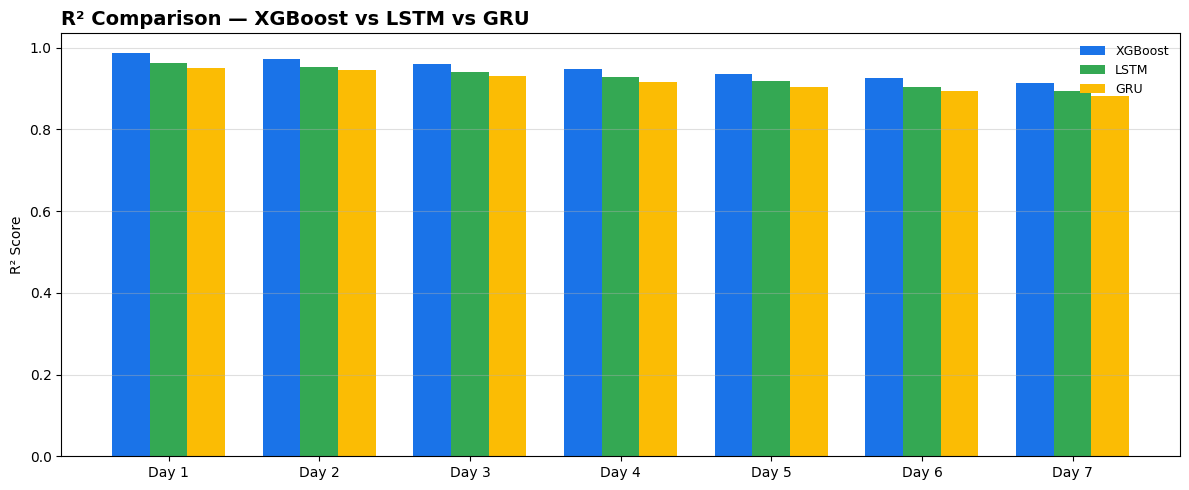

In [ ]:
xgb_r2, lstm_r2, gru_r2 = [], [], []

for day in range(1, 8):
    preds = models_v2[day].predict(X_test_v2_scaled)
    xgb_r2.append(r2_score(y_test_v2[f'target_day_{day}'].values, preds))

    lstm_preds = lstm_models[day]['model'].predict(lstm_models[day]['X_test'], verbose=0).flatten()
    lstm_r2.append(r2_score(lstm_models[day]['y_test'], lstm_preds))

    gru_preds = gru_models[day]['model'].predict(gru_models[day]['X_test'], verbose=0).flatten()
    gru_r2.append(r2_score(gru_models[day]['y_test'], gru_preds))

days = [f'Day {i}' for i in range(1, 8)]
x = np.arange(len(days))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, xgb_r2, width, label='XGBoost', color='#1A73E8')
ax.bar(x,          lstm_r2, width, label='LSTM',    color='#34A853')
ax.bar(x + width,  gru_r2,  width, label='GRU',     color='#FBBC04')

ax.set_title('R² Comparison — XGBoost vs LSTM vs GRU', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('R² Score')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.legend(fontsize=9, framealpha=0)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


# Save Final Model (deployable artifacts)

In [ ]:
# Final model trained on the SAME features/params validated by walk-forward above,
# so the deployed model's expected performance matches the reported numbers.

dump(models_v2, 'models_v2.joblib')
dump(scaler_v2, 'scaler_v2.joblib')
dump(feature_cols_v2, 'feature_cols_v2.joblib')

print("✅ Saved: models_v2.joblib, scaler_v2.joblib, feature_cols_v2.joblib")
print("Features:", len(feature_cols_v2), "| Scaler expects:", scaler_v2.n_features_in_, "| Model expects:", models_v2[1].n_features_in_)


✅ Saved: models_v2.joblib, scaler_v2.joblib, feature_cols_v2.joblib
Features: 19 | Scaler expects: 19 | Model expects: 19


In [ ]:
from google.colab import files
files.download('models_v2.joblib')
files.download('scaler_v2.joblib')
files.download('feature_cols_v2.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>